In [36]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [37]:
df = pd.read_csv("city_day.csv")

In [38]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [39]:
df.shape

(29531, 16)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [41]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [42]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [43]:
df["AQI"].describe()

,AQI
count,24850.000000
mean,166.463581
std,140.696585
min,13.000000
25%,81.000000
50%,118.000000
75%,208.000000
max,2049.000000


In [44]:
df["AQI"].isnull().sum()

np.int64(4681)

In [45]:
df.duplicated().sum()

np.int64(0)

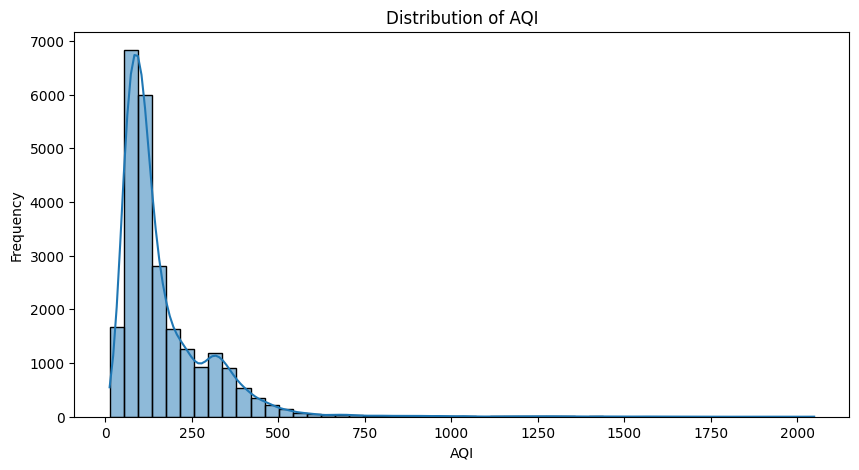

In [46]:
#EDA AQI distribution
plt.figure(figsize=(10,5))

sns.histplot(df["AQI"].dropna(), bins=50, kde=True)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

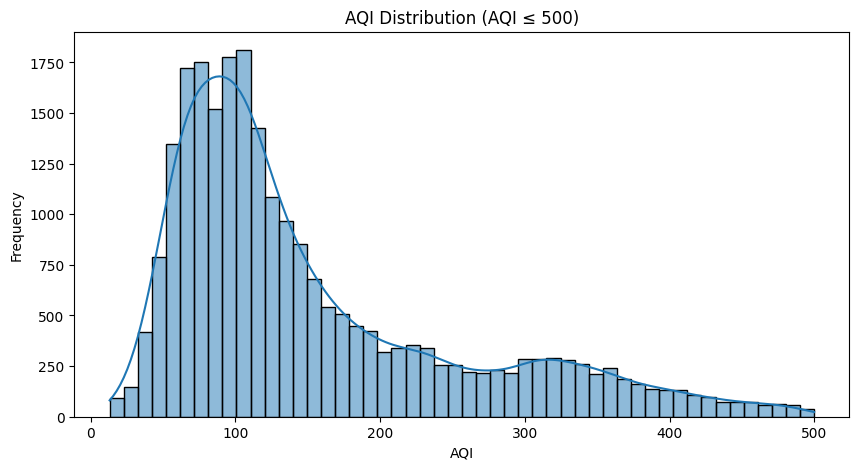

In [47]:
#Normal AQi distribution
plt.figure(figsize=(10,5))

sns.histplot(df.loc[df["AQI"] <= 500, "AQI"].dropna(), bins=50, kde=True)

plt.title("AQI Distribution (AQI ≤ 500)")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

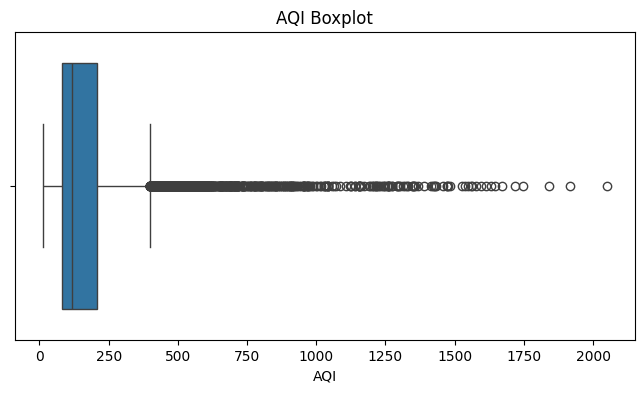

In [48]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["AQI"])

plt.title("AQI Boxplot")
plt.xlabel("AQI")
plt.show()

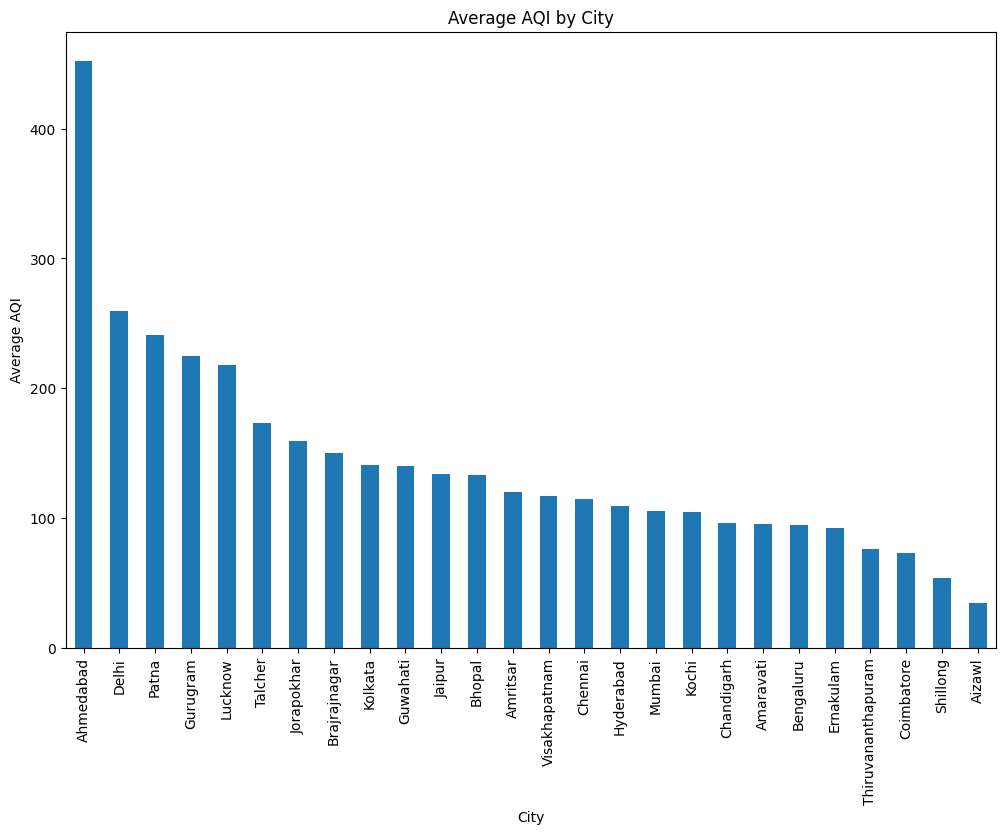

In [49]:
city_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

city_aqi.plot(kind="bar")

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)

plt.show()

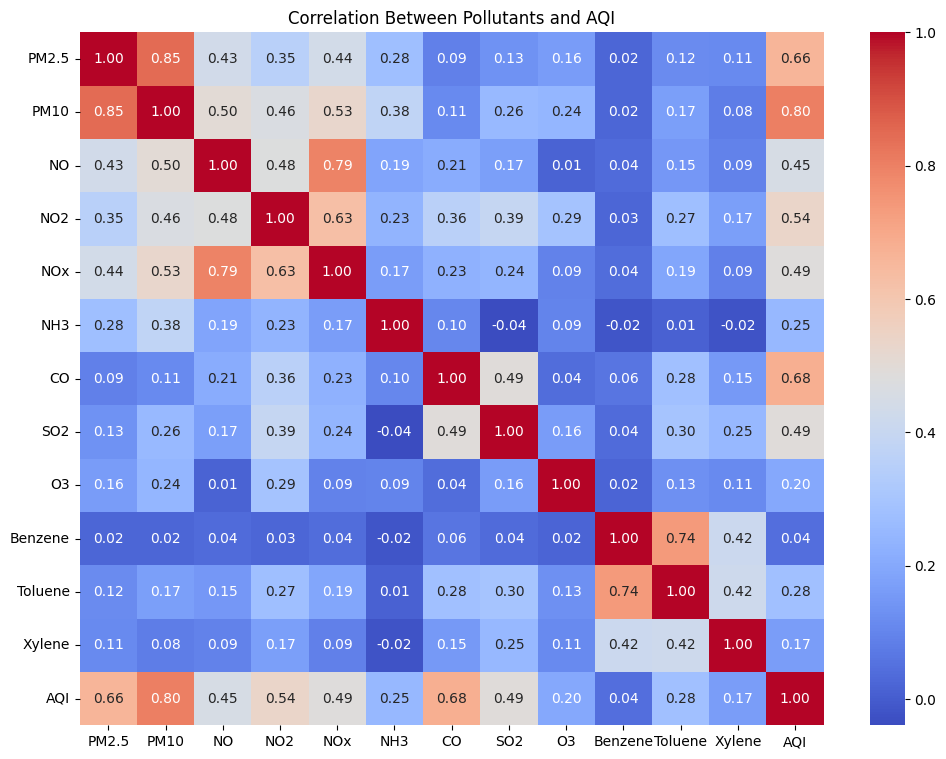

In [50]:
pollutant_cols = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene", "AQI"
]

correlation = df[pollutant_cols].corr()

plt.figure(figsize=(12,9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Pollutants and AQI")
plt.show()

In [51]:
#AQI changes over the period
df["Date"] = pd.to_datetime(df["Date"])

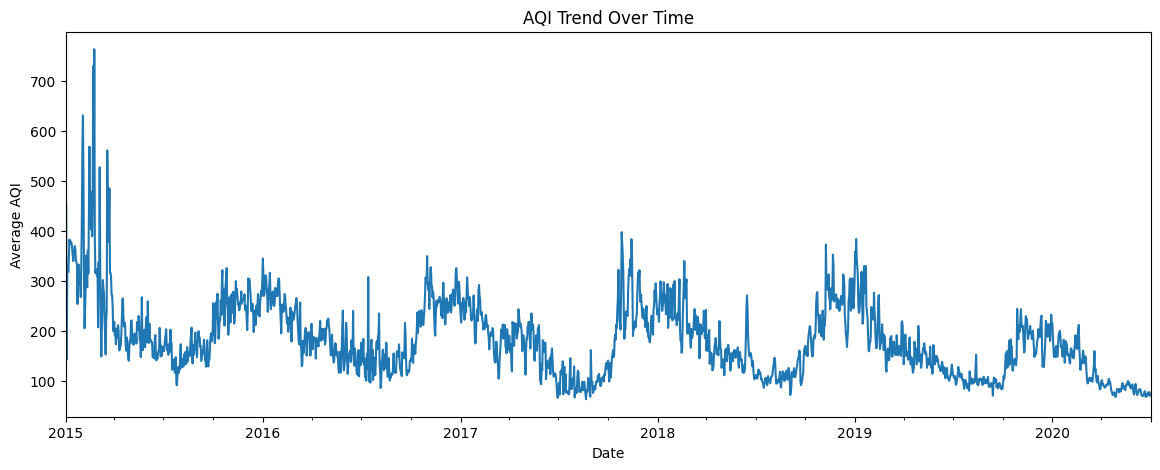

In [52]:
daily_aqi = df.groupby("Date")["AQI"].mean()

plt.figure(figsize=(14,5))

daily_aqi.plot()

plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average AQI")

plt.show()

In [53]:
#Data cleaning
#Checking which rows are missing AQI
df[df["AQI"].isnull()].head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [54]:
print("Rows with missing AQI:", df["AQI"].isnull().sum())
print("Rows with AQI:", df["AQI"].notnull().sum())

Rows with missing AQI: 4681
Rows with AQI: 24850


In [55]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Number of cities:", df["City"].nunique())
print(df["City"].value_counts())

Start date: 2015-01-01 00:00:00
End date: 2020-07-01 00:00:00
Number of cities: 26
City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Mumbai                2009
Lucknow               2009
Delhi                 2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64


In [56]:
missing_pollutants = df[
    ["PM2.5", "PM10", "NO", "NO2", "NOx",
     "NH3", "CO", "SO2", "O3",
     "Benzene", "Toluene", "Xylene"]
].isnull().sum()

print(missing_pollutants)

PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4185
NH3        10328
CO          2059
SO2         3854
O3          4022
Benzene     5623
Toluene     8041
Xylene     18109
dtype: int64


In [57]:
missing_percent = (
    df[
        ["PM2.5", "PM10", "NO", "NO2", "NOx",
         "NH3", "CO", "SO2", "O3",
         "Benzene", "Toluene", "Xylene"]
    ].isnull().mean() * 100
)

print(missing_percent.sort_values(ascending=False))

Xylene     61.322001
PM10       37.723071
NH3        34.973418
Toluene    27.229014
Benzene    19.041008
PM2.5      15.570079
NOx        14.171549
O3         13.619586
SO2        13.050692
NO2        12.139785
NO         12.129626
CO          6.972334
dtype: float64


In [58]:
#removing xylene because it's missing 61.32% of the records
df = df.drop(columns=["Xylene"])

In [59]:
#Removing rows with missing AQI
df = df.dropna(subset=["AQI"])

In [60]:
print("Dataset shape after cleaning target:", df.shape)

Dataset shape after cleaning target: (24850, 15)


In [61]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,678
PM10,7086
NO,387
NO2,391
NOx,1857
NH3,6536
CO,445
SO2,605


In [63]:
#feature Engineering
#using Median Imputation
pollutant_cols = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene"
]

for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].median())

In [64]:
df[pollutant_cols].isnull().sum()

,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0
O3,0
Benzene,0


In [65]:
#AQI_Bucket is based on the AQI value itself.
#If we leave it in the model, the model can indirectly get the answer
df = df.drop(columns=["AQI_Bucket"])

In [66]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
28,Ahmedabad,2015-01-29,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,209.0
29,Ahmedabad,2015-01-30,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,328.0
30,Ahmedabad,2015-01-31,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,514.0
31,Ahmedabad,2015-02-01,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,782.0
32,Ahmedabad,2015-02-02,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,914.0


In [67]:
df["Date"] = pd.to_datetime(df["Date"])

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24850 entries, 28 to 29530
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   City     24850 non-null  object        
 1   Date     24850 non-null  datetime64[ns]
 2   PM2.5    24850 non-null  float64       
 3   PM10     24850 non-null  float64       
 4   NO       24850 non-null  float64       
 5   NO2      24850 non-null  float64       
 6   NOx      24850 non-null  float64       
 7   NH3      24850 non-null  float64       
 8   CO       24850 non-null  float64       
 9   SO2      24850 non-null  float64       
 10  O3       24850 non-null  float64       
 11  Benzene  24850 non-null  float64       
 12  Toluene  24850 non-null  float64       
 13  AQI      24850 non-null  float64       
dtypes: datetime64[ns](1), float64(12), object(1)
memory usage: 2.8+ MB


In [69]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_week"] = df["Date"].dt.dayofweek

In [70]:
df = df.drop(columns=["Date"])

In [71]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 24850 entries, 28 to 29530
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         24850 non-null  object 
 1   PM2.5        24850 non-null  float64
 2   PM10         24850 non-null  float64
 3   NO           24850 non-null  float64
 4   NO2          24850 non-null  float64
 5   NOx          24850 non-null  float64
 6   NH3          24850 non-null  float64
 7   CO           24850 non-null  float64
 8   SO2          24850 non-null  float64
 9   O3           24850 non-null  float64
 10  Benzene      24850 non-null  float64
 11  Toluene      24850 non-null  float64
 12  AQI          24850 non-null  float64
 13  Year         24850 non-null  int32  
 14  Month        24850 non-null  int32  
 15  Day          24850 non-null  int32  
 16  Day_of_week  24850 non-null  int32  
dtypes: float64(12), int32(4), object(1)
memory usage: 3.0+ MB


,0
City,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0
O3,0


In [72]:
X = df.drop("AQI", axis=1)
y = df["AQI"]

In [73]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24850, 16)
y shape: (24850,)


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [75]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (19880, 16)
Testing data: (4970, 16)


In [76]:
categorical_features = ["City"]

numerical_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Year",
    "Month",
    "Day",
    "Day_of_week"
]

In [77]:
print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Categorical features: ['City']
Number of numerical features: 15


In [78]:
#onehotencoding for city
#standardscaler for numerical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [80]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

In [81]:
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_models[name] = pipeline

In [82]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,20.407584,40.250789,0.911522
1,Gradient Boosting,23.121438,42.979138,0.899121
2,Decision Tree,28.135815,54.498941,0.837795
3,Linear Regression,29.966309,56.695814,0.824455


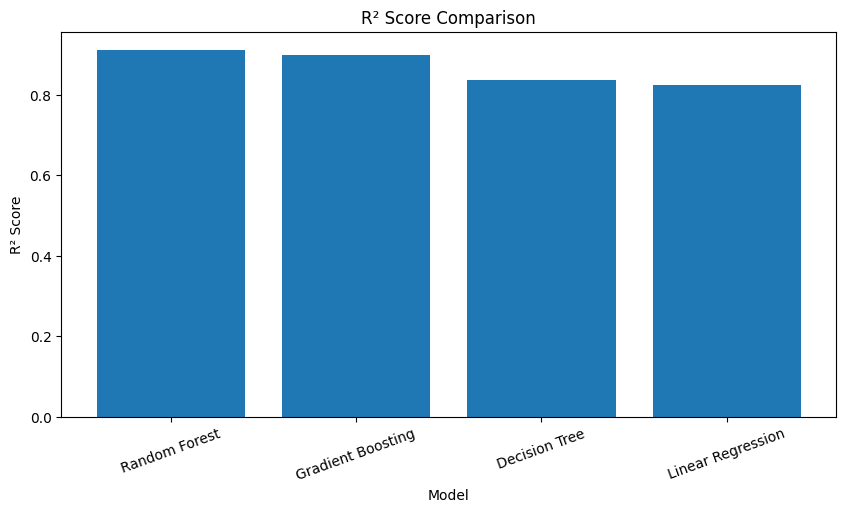

In [83]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

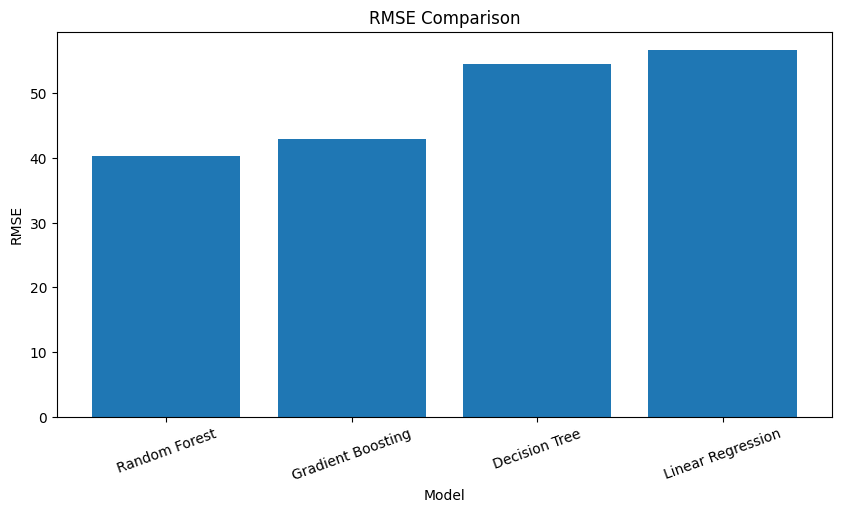

In [84]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

In [86]:
best_model = trained_models["Random Forest"]
y_pred = best_model.predict(X_test)

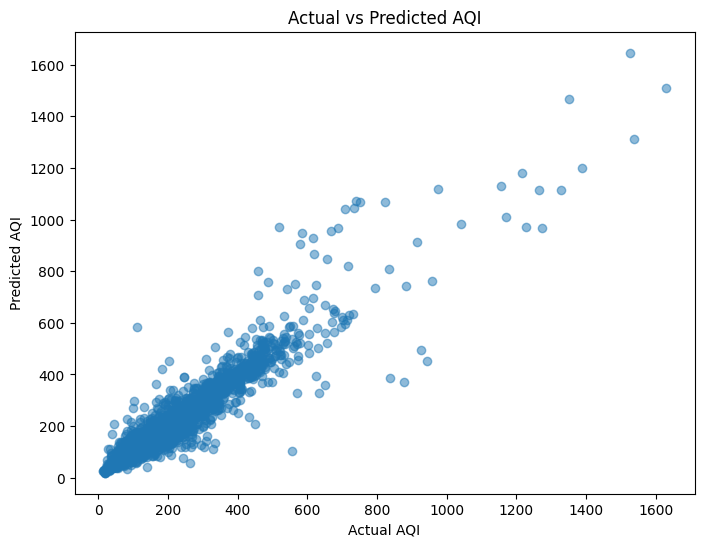

In [87]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

In [88]:
comparison = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": y_pred
})

comparison.head(15)

,Actual AQI,Predicted AQI
0,141.0,108.91
1,209.0,207.85
2,111.0,99.30
3,124.0,141.16
4,81.0,78.86
5,54.0,63.79
6,74.0,63.80
7,99.0,104.67
8,97.0,136.93
9,60.0,60.04


In [89]:
best_model = trained_models["Random Forest"]

preprocessor_fitted = best_model.named_steps["preprocessor"]
rf_model = best_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,num__PM2.5,0.489331
6,num__CO,0.366121
1,num__PM10,0.035454
2,num__NO,0.035376
8,num__O3,0.012502
4,num__NOx,0.009568
7,num__SO2,0.008175
10,num__Toluene,0.006927
3,num__NO2,0.006221
13,num__Day,0.005540


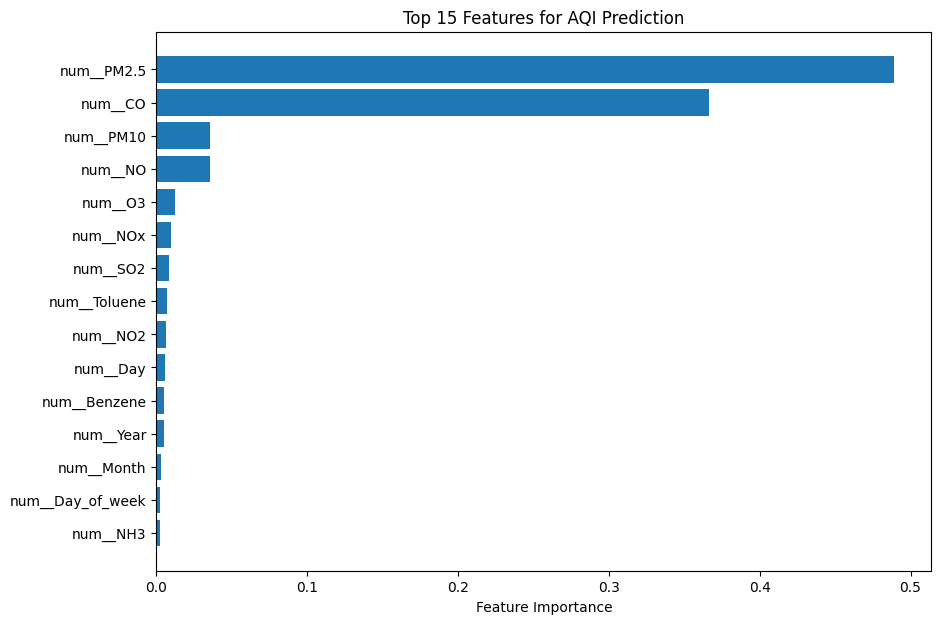

In [90]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Features for AQI Prediction")
plt.xlabel("Feature Importance")

plt.show()

In [92]:
import joblib
joblib.dump(best_model, "aqi_random_forest_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [124]:
#demo
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]

print("Predicted AQI:", round(prediction, 2))
print("Actual AQI:", round(y_test.iloc[0], 2))

Predicted AQI: 108.91
Actual AQI: 141.0


In [125]:
sample

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Year,Month,Day,Day_of_week
8450,Chennai,42.37,96.18,4.37,15.42,16.21,16.31,1.03,4.94,36.09,0.76,2.04,2016,9,8,3
